In [1]:
#Import all necessay libraries.
import pickle as pkl
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

import atomai as aoi
from atomai.utils import create_lattice_mask, extract_patches_
from atomai.transforms import datatransform

In [2]:
from instance_seg_utils import *

### Load Dataset

In [3]:
import pickle 

with open("SMILE_dataset.pkl", "rb") as f: 
    data = pickle.load(f)                    #corresponds to SMILE selected images

images_all = data["images"]
masks_all = data["masks"]

print("Number of samples:", len(images_all))

Number of samples: 24


In [5]:
import matplotlib.pyplot as plt

def visualize_images_and_masks(images, masks, num_samples=24):
    """
    Visualizes pairs of images and their corresponding masks.

    Parameters:
    - images: List of NumPy arrays representing images.
    - masks: List of NumPy arrays representing masks.
    - num_samples: Number of samples to visualize.
    """
    num_samples = min(num_samples, len(images), len(masks))

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 3))
    
    for i in range(num_samples):
        #Show the image
        axes[i, 0].imshow(images[i], cmap='gray')
        axes[i, 0].set_title(f"Image {i+1}")
        axes[i, 0].axis('off')

        #Show the corresponding mask
        axes[i, 1].imshow(masks[i], cmap='gray')
        axes[i, 1].set_title(f"Mask {i+1}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

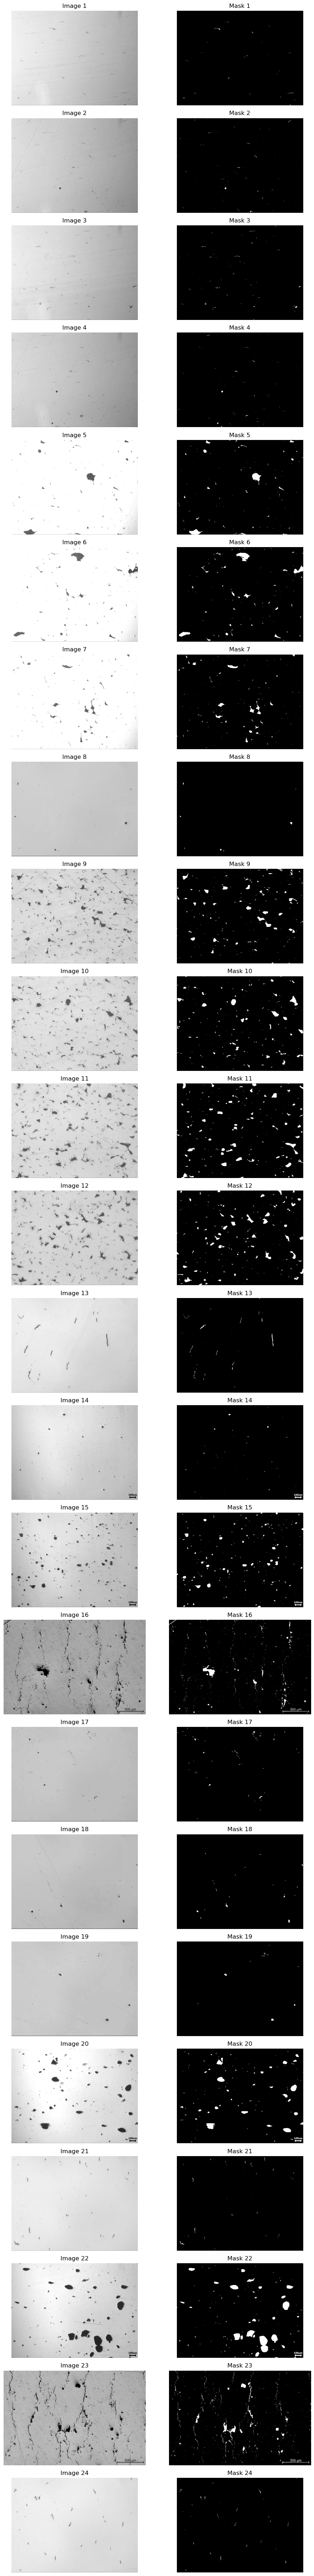

In [6]:
visualize_images_and_masks(images_all, masks_all) #visualise

In [7]:
images_all[1].shape 

(1536, 2048)

### Train-Test Split

In [8]:
images_train, images_test, masks_train, masks_test= train_test_split(images_all,masks_all,test_size=0.01, random_state=120
                                                                )

In [9]:
print(len(images_train))

23


In [10]:
# for i, (image, mask) in enumerate(zip(images_train, masks_train)):
#     print(f"Image {i} shape: {image.shape}, Mask {i} shape: {mask.shape}")

In [11]:
len(images_test)

1

In [13]:
# Visualise test image

# for i in range(len(images_test)):
#     plt.imshow(images_test[i], cmap='gray')
#     plt.show()

### Making patches for training

In [15]:
def patch_base(images,labels):


    images_full, labels_full = extract_patches_(images[0], labels[0], patch_size=256, num_patches=500, random_state=42)

    for i in range(1,len(images)):
        images_all, labels_all = extract_patches_(images[i], labels[i], patch_size=256, num_patches=500, random_state=42)
        images_full=np.concatenate((images_full,images_all))
        labels_full=np.concatenate((labels_full,labels_all))
    return images_full,labels_full

In [16]:
images_all,labels_all=patch_base(images_train,masks_train)

In [17]:
print(images_all.shape)

(11500, 256, 256)


In [18]:
print(labels_all.shape)

(11500, 256, 256)


### Patch Augmentation

In [19]:
# Define image distortion/noise parameters
ch=1
zoom = 1.1 # zoom factor
poisson = [30, 40] # P noise range
gauss = [20, 100] # G noise range 
blur = [1, 40] # Blurring range
contrast = [5, 14] # contrast range
salt_and_pepper = [1, 10] # min/max amount of salted/peppered pixels
# Run the augmentor
imaug = datatransform(
    n_channels=ch, dim_order_in='channel_last', dim_order_out='channel_first',
    gauss_noise=gauss, poisson_noise=poisson, salt_and_pepper=salt_and_pepper,
    contrast=contrast, blur=blur, zoom=zoom, rotation=True,
    squeeze_channels=False, seed=42)
images_all, labels_all = imaug.run(images_all, labels_all)

print(images_all.shape, labels_all.shape)

(11500, 1, 256, 256) (11500, 256, 256)


In [20]:
images, images_val, labels, labels_val = train_test_split(images_all, labels_all, test_size=0.2, random_state=42)

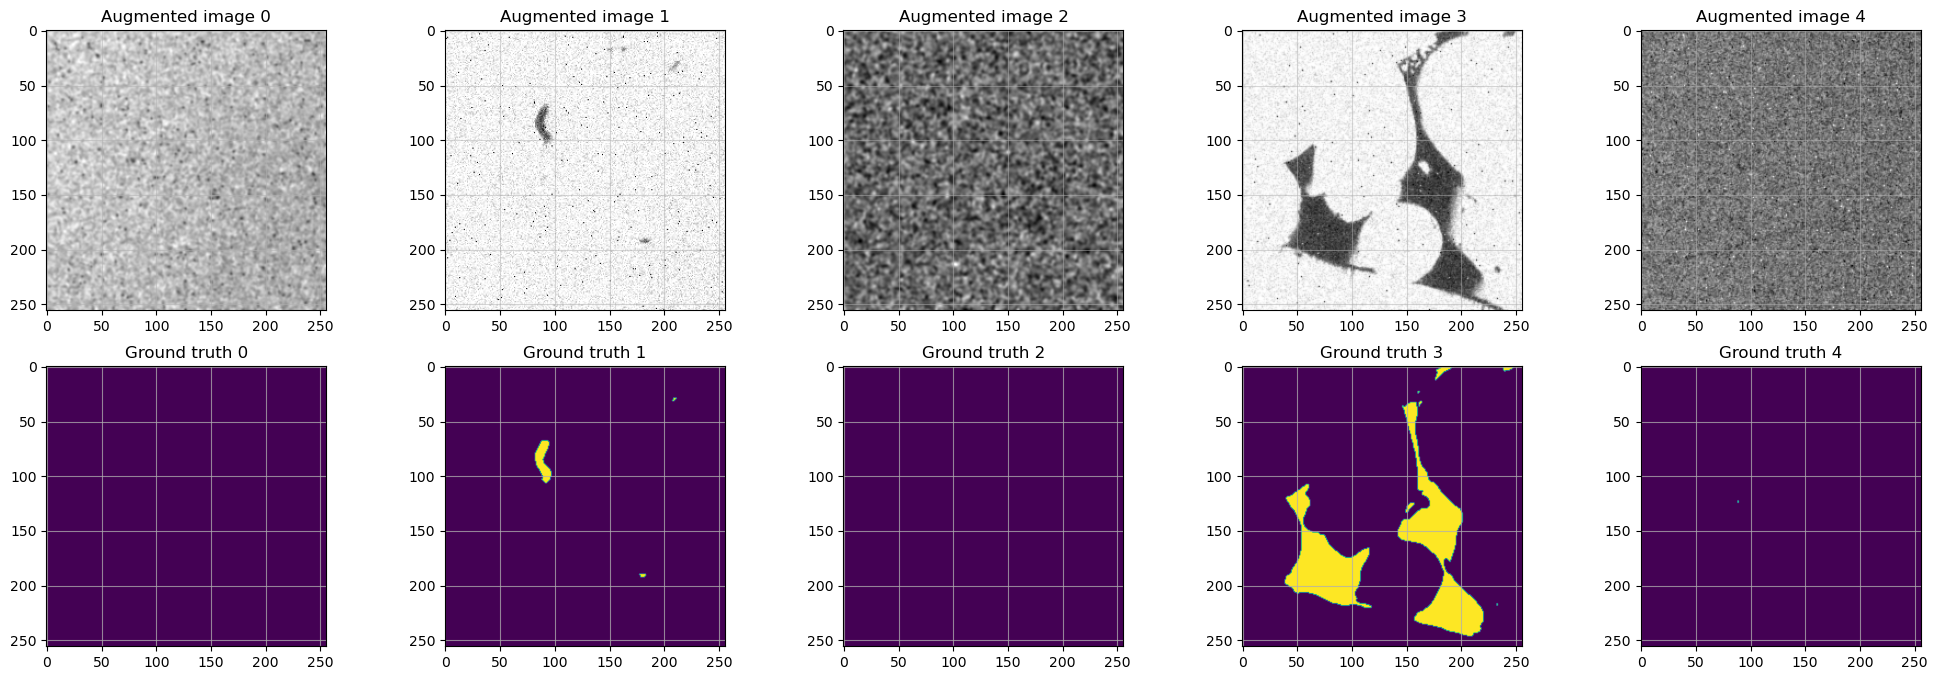

In [21]:
n = 5
k=1
n = n + 1
fig = plt.figure( figsize=(30, 8))
for i in range(1, n):
    ax = fig.add_subplot(2, n, i)
    ax.imshow(images[i-1+k,0,:,:], cmap='gray')
    ax.set_title('Augmented image ' + str(i-1) )
    ax.grid(alpha = 0.5)
    ax = fig.add_subplot(2, n, i+n)
    if labels.shape[1] == 1:
        ax.imshow(labels[i-1+k, 0], cmap='gray', interpolation='Gaussian')
    else:
        ax.imshow(labels[i-1+k], interpolation='Gaussian')
    ax.set_title('Ground truth ' + str(i-1))
    ax.grid(alpha=0.75)

### Model Training (U-Net)

In [22]:
model = aoi.models.Segmentor(model='Unet',nb_classes=1) #AtomAI Unet

In [23]:
print(model.net)

Unet(
  (c1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (c2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): LeakyReLU(negative_slope=0.01)
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (c3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [24]:
lr_rates=[1e-3,1e-4,1e-5]
lr_rates=np.repeat(lr_rates,20)
#1e-3 for 20 iters, 1e-4 for next 20, 1e-5 for the rest

/home/hitesh/.conda/envs/cvat_env/lib/python3.9/site-packages/atomai/utils/preproc.py:64: UserWarning: Adding a channel dimension of 1 to training labels
  warnings.warn(
/home/hitesh/.conda/envs/cvat_env/lib/python3.9/site-packages/atomai/utils/preproc.py:69: UserWarning: Adding a channel dimension of 1 to test labels
  warnings.warn(


Epoch 1/5000 ... Training loss: 0.258027 ... Test loss: 0.036054 ... Train Accuracy: 0.656816 ... Test Accuracy: 0.786839 ... GPU memory usage: 2238/20470
Updating ES model @ Epoch 1/5000 ... Training loss: 0.258027 ... Test loss: 0.036054 ... Train Accuracy: 0.656816 ... Test Accuracy: 0.786839 ... GPU memory usage: 2238/20470
Epoch 2/5000 ... Training loss: 0.021752 ... Test loss: 0.015222 ... Train Accuracy: 0.805681 ... Test Accuracy: 0.817514 ... GPU memory usage: 2240/20470
Updating ES model @ Epoch 2/5000 ... Training loss: 0.021752 ... Test loss: 0.015222 ... Train Accuracy: 0.805681 ... Test Accuracy: 0.817514 ... GPU memory usage: 2240/20470
Epoch 3/5000 ... Training loss: 0.014488 ... Test loss: 0.028062 ... Train Accuracy: 0.807343 ... Test Accuracy: 0.795698 ... GPU memory usage: 2240/20470
Epoch 4/5000 ... Training loss: 0.011701 ... Test loss: 0.009604 ... Train Accuracy: 0.822582 ... Test Accuracy: 0.835506 ... GPU memory usage: 2240/20470
Updating ES model @ Epoch 4/50

Epoch 35/5000 ... Training loss: 0.005296 ... Test loss: 0.005622 ... Train Accuracy: 0.899106 ... Test Accuracy: 0.890207 ... GPU memory usage: 2240/20470
Epoch 36/5000 ... Training loss: 0.005244 ... Test loss: 0.005614 ... Train Accuracy: 0.899149 ... Test Accuracy: 0.890942 ... GPU memory usage: 2240/20470
Epoch 37/5000 ... Training loss: 0.005171 ... Test loss: 0.005544 ... Train Accuracy: 0.900142 ... Test Accuracy: 0.892124 ... GPU memory usage: 2240/20470
Updating ES model @ Epoch 37/5000 ... Training loss: 0.005171 ... Test loss: 0.005544 ... Train Accuracy: 0.900142 ... Test Accuracy: 0.892124 ... GPU memory usage: 2240/20470
Epoch 38/5000 ... Training loss: 0.005131 ... Test loss: 0.005537 ... Train Accuracy: 0.901028 ... Test Accuracy: 0.892862 ... GPU memory usage: 2240/20470
Epoch 39/5000 ... Training loss: 0.00508 ... Test loss: 0.005505 ... Train Accuracy: 0.903166 ... Test Accuracy: 0.892601 ... GPU memory usage: 2240/20470
Epoch 40/5000 ... Training loss: 0.005037 ...

Epoch 86/5000 ... Training loss: 0.004656 ... Test loss: 0.005353 ... Train Accuracy: 0.910518 ... Test Accuracy: 0.896949 ... GPU memory usage: 2240/20470
Epoch 87/5000 ... Training loss: 0.004665 ... Test loss: 0.005355 ... Train Accuracy: 0.910261 ... Test Accuracy: 0.896393 ... GPU memory usage: 2240/20470
Epoch 88/5000 ... Training loss: 0.004634 ... Test loss: 0.005352 ... Train Accuracy: 0.909917 ... Test Accuracy: 0.896847 ... GPU memory usage: 2240/20470
Epoch 89/5000 ... Training loss: 0.004637 ... Test loss: 0.005361 ... Train Accuracy: 0.910435 ... Test Accuracy: 0.896802 ... GPU memory usage: 2240/20470
Epoch 90/5000 ... Training loss: 0.004634 ... Test loss: 0.005345 ... Train Accuracy: 0.911159 ... Test Accuracy: 0.896559 ... GPU memory usage: 2240/20470
Epoch 91/5000 ... Training loss: 0.004622 ... Test loss: 0.00535 ... Train Accuracy: 0.910742 ... Test Accuracy: 0.897419 ... GPU memory usage: 2240/20470
Epoch 92/5000 ... Training loss: 0.004616 ... Test loss: 0.005355

Epoch 138/5000 ... Training loss: 0.004401 ... Test loss: 0.005299 ... Train Accuracy: 0.914309 ... Test Accuracy: 0.899344 ... GPU memory usage: 2240/20470
Epoch 139/5000 ... Training loss: 0.004391 ... Test loss: 0.00533 ... Train Accuracy: 0.914112 ... Test Accuracy: 0.898683 ... GPU memory usage: 2240/20470
Epoch 140/5000 ... Training loss: 0.004407 ... Test loss: 0.005293 ... Train Accuracy: 0.914054 ... Test Accuracy: 0.899299 ... GPU memory usage: 2240/20470
Epoch 141/5000 ... Training loss: 0.004404 ... Test loss: 0.005325 ... Train Accuracy: 0.914775 ... Test Accuracy: 0.898622 ... GPU memory usage: 2240/20470
Epoch 142/5000 ... Training loss: 0.004399 ... Test loss: 0.005295 ... Train Accuracy: 0.914294 ... Test Accuracy: 0.898961 ... GPU memory usage: 2240/20470
Epoch 143/5000 ... Training loss: 0.00437 ... Test loss: 0.005303 ... Train Accuracy: 0.914999 ... Test Accuracy: 0.898906 ... GPU memory usage: 2240/20470
Epoch 144/5000 ... Training loss: 0.004366 ... Test loss: 0.

Epoch 191/5000 ... Training loss: 0.0042 ... Test loss: 0.005265 ... Train Accuracy: 0.918218 ... Test Accuracy: 0.900399 ... GPU memory usage: 2240/20470
Epoch 192/5000 ... Training loss: 0.004188 ... Test loss: 0.005247 ... Train Accuracy: 0.918676 ... Test Accuracy: 0.901308 ... GPU memory usage: 2240/20470
Epoch 193/5000 ... Training loss: 0.004181 ... Test loss: 0.005277 ... Train Accuracy: 0.919637 ... Test Accuracy: 0.90058 ... GPU memory usage: 2240/20470
Epoch 194/5000 ... Training loss: 0.004183 ... Test loss: 0.005249 ... Train Accuracy: 0.9196 ... Test Accuracy: 0.90091 ... GPU memory usage: 2240/20470
Epoch 195/5000 ... Training loss: 0.004183 ... Test loss: 0.005259 ... Train Accuracy: 0.919687 ... Test Accuracy: 0.900839 ... GPU memory usage: 2240/20470
Epoch 196/5000 ... Training loss: 0.004163 ... Test loss: 0.005255 ... Train Accuracy: 0.919134 ... Test Accuracy: 0.901302 ... GPU memory usage: 2240/20470
Epoch 197/5000 ... Training loss: 0.004163 ... Test loss: 0.0052

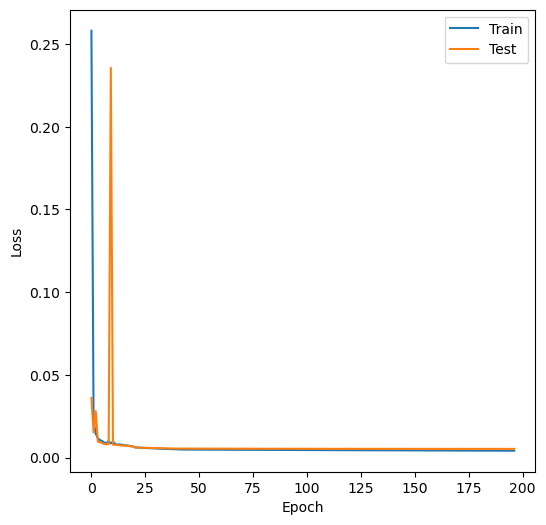

Calculating Automatic Threshold
Batch 2300/2300
2300 images were decoded in approximately 9.0482 seconds


In [153]:
model.fit(images, labels, images_val, labels_val, # training data
         training_cycles=5000, compute_accuracy=True, batch_size=16, swa=False, filename='Seg2Inst_comb',
         ES=True, patience=100,tolerance=1e-4,verbose=True,auto_thresh=True, full_epoch=True,
         lr_scheduler=lr_rates)

In [25]:
# import torch

# model_save_path = "seg_model.pth"

# torch.save(model.net.state_dict(), model_save_path)

### Load the trained model

In [28]:
new_model = aoi.models.Segmentor(nb_classes=1) 
model_load_path = "seg_model.pth"
new_model.load_weights(model_load_path) 

/home/hitesh/.conda/envs/cvat_env/lib/python3.9/site-packages/atomai/models/segmentor.py:289: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weight_dict = torch.load(filepath

In [29]:
images_test = [np.asarray(im, dtype=np.float32) for im in images_test]

In [30]:
preds_probs = []
for im in images_test:
    pred_m = new_model.predict(im)[0][0]
    preds_probs.append(pred_m)

Batch 1/1
1 image was decoded in approximately 0.1981 seconds


In [33]:
# plt.imshow(preds_probs[0], cmap='gray')

In [34]:
# mask_test = np.array(masks_test[0], dtype=np.uint8)

# plt.imshow(mask_test, cmap='gray')
# plt.axis('off')
# plt.show()

### Visualise predictions

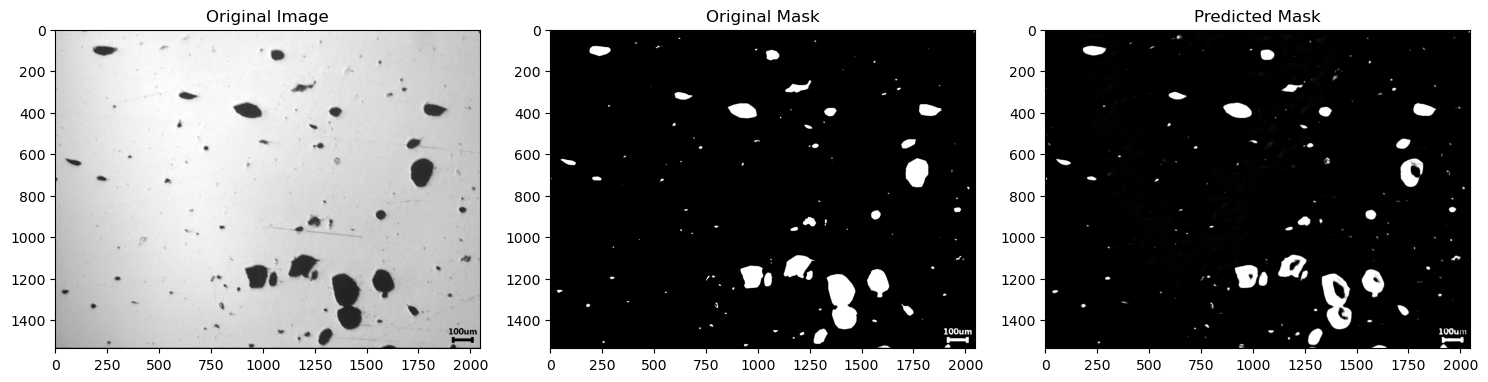

In [42]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(images_test[0].squeeze(), cmap="gray") 

plt.subplot(1, 3, 2)
plt.title("Original Mask")
plt.imshow(mask_test, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(preds_probs[0], cmap="gray")
# plt.imshow(output_mask1, cmap="gray")

plt.tight_layout()
plt.show()

In [36]:
# preds_probs[0]

In [37]:
import numpy as np
import torch

def make_binary_masks(masks):
    
    if isinstance(masks, torch.Tensor):
        masks = masks.cpu().numpy() 

    binary_masks = (masks >= 0.5).astype(np.uint8)
    
    unique_values_after = np.unique(binary_masks)
    print(f"Unique values in masks after conversion: {unique_values_after}")
    
    return binary_masks


In [38]:
#output_mask1 = make_binary_masks(preds_probs[0])

In [39]:
bin_pred_masks = []
for i in range (len(preds_probs)):
    bin_pred_mask = make_binary_masks(preds_probs[i])
    bin_pred_masks.append(bin_pred_mask)

Unique values in masks after conversion: [0 1]


In [40]:
#print(masks_test[0].shape, output_mask1.shape)

### Check performance

In [43]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from PIL import Image

def load_binary_mask(mask_path):
    mask = Image.open(mask_path)
    mask = mask.convert('1')  # Convert to binary image
    return np.array(mask)

def calculate_metrics(ground_truth, prediction):
    
    ground_truth_flat = ground_truth.flatten() # Flatten the arrays to 1D
    
    prediction_flat = prediction.flatten()
    
    accuracy = accuracy_score(ground_truth_flat, prediction_flat) # Calculate accuracy
   
    precision = precision_score(ground_truth_flat, prediction_flat, zero_division=1)  # Calculate precision

    recall = recall_score(ground_truth_flat, prediction_flat, zero_division=1) # Calculate recall score

    f1 = f1_score(ground_truth_flat, prediction_flat, zero_division=1)     # Calculate F1 score

    intersection = np.logical_and(ground_truth_flat, prediction_flat).sum()     # Calculate IoU
    
    union = np.logical_or(ground_truth_flat, prediction_flat).sum()
    
    iou = intersection / union if union != 0 else 0
 
    dice = 2 * intersection / (ground_truth_flat.sum() + prediction_flat.sum())    # Calculate Dice coefficient
    
    return accuracy, precision, recall, f1, iou, dice


In [44]:
accuracies, precisions, recalls, f1_scores, ious, dices = [], [], [], [], [], []

for gt_mask, pred_mask in zip(masks_test, bin_pred_masks):
    accuracy, precision, recall, f1, iou, dice = calculate_metrics(gt_mask, pred_mask)
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    ious.append(iou)
    dices.append(dice)


print('accuracy', accuracies)
print('precision', precisions)
print('recall', recalls)
print('f1score', f1_scores)
print('iou',ious)
print('dice', dices)

accuracy [0.9918286005655924]
precision [0.9131113603036315]
recall [0.8713299146424779]
f1score [0.8917314957943552]
iou [0.8046168346483027]
dice [0.8917314957943552]
